# Machine Learning Pipeline for Queen Bee Acoustic Monitoring

# Import Library & Setup Environment

In [ ]:
import os
import torch
import torchaudio
import pandas as pd
import numpy as np
import random
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from torch.amp import GradScaler, autocast
from sklearn.model_selection import StratifiedGroupKFold
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
from sklearn.metrics import confusion_matrix, classification_report, recall_score, f1_score

In [ ]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Run Model on: {DEVICE}")

Run Model on: cuda


In [ ]:
RAW_AUDIO_DIR = 'dataset'
LABEL_CSV = 'dataset/state_labels.csv'

In [ ]:
WINDOW_SEC = 5.0

df_labels = pd.read_csv(LABEL_CSV)
new_records = []

print("Finding all audio files in folder")
audio_files_map = {}
for root, dirs, files in os.walk(RAW_AUDIO_DIR):
    for file in files:
        if file.endswith('.wav') or file.endswith('.mp3'):
            base_name = os.path.splitext(file)[0]
            audio_files_map[base_name] = os.path.join(root, file)

print(f"Find all {len(audio_files_map)} File (Ready for matching with CSV)")

print("Start slicing audio file")
for _, row in tqdm(df_labels.iterrows(), total=len(df_labels)):
    sample_name = str(row['sample_name']).strip()
    label = str(row['label']).strip().lower()

    if label not in ['active', 'missing queen']: continue
    
    if sample_name not in audio_files_map:
        continue 
        
    file_path = audio_files_map[sample_name]
        
    try:
        info = torchaudio.info(file_path)
        sr = info.sample_rate
        total_frames = info.num_frames
        chunk_frames = int(sr * WINDOW_SEC)
        
        for start_frame in range(0, total_frames, chunk_frames):
            end_frame = start_frame + chunk_frames
            if end_frame > total_frames: break # ทิ้งเศษท้ายคลิป
            
            numeric_label = 0 if label == 'active' else 1
            new_records.append({
                'audio_path': file_path,
                'hive_id': sample_name.split('_')[0], 
                'start_frame': start_frame,
                'num_frames': chunk_frames,
                'label': numeric_label
            })

    except Exception as e:
        pass

df_processed = pd.DataFrame(new_records)
df_processed.to_csv('virtual_hive_state_dataset.csv', index=False)
print(f"Finish slicing audio files, received {len(df_processed)} Files")

Finding all audio files in folder
Find all 576 File (Ready for matching with CSV)
Start slicing audio file


  0%|          | 0/573 [00:00<?, ?it/s]

Finish slicing audio files, received 67049 Files


In [ ]:
TARGET_SR = 16000

class VirtualHiveStateDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df = df.reset_index(drop=True)
        self.augment = augment
        self.resampler = torchaudio.transforms.Resample(orig_freq=22050, new_freq=TARGET_SR)
        
        self.mel_spectrogram = torchaudio.transforms.MelSpectrogram(
            sample_rate=TARGET_SR,
            n_mels=64,
            n_fft=1024,
            hop_length=512
        )
        self.amplitude_to_db = torchaudio.transforms.AmplitudeToDB()

    def __len__(self): return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        start_frame = int(row['start_frame'])
        num_frames = int(row['num_frames'])

        try:
            waveform, sr = torchaudio.load(row['audio_path'], frame_offset=start_frame, num_frames=num_frames)

            if sr != TARGET_SR:
                waveform = self.resampler(waveform)
            if waveform.shape[0] > 1:
                waveform = torch.mean(waveform, dim=0, keepdim=True)

            max_frames = TARGET_SR * 5  
            
            if waveform.shape[1] > max_frames:
                if self.augment:
                    start_idx = random.randint(0, waveform.shape[1] - max_frames)
                    waveform = waveform[:, start_idx : start_idx + max_frames]
                else:
                    waveform = waveform[:, :max_frames]
                    
            elif waveform.shape[1] < max_frames:
                padding = max_frames - waveform.shape[1]
                waveform = F.pad(waveform, (0, padding))

            if self.augment:
                waveform = waveform * random.uniform(0.7, 1.2)
                if random.random() < 0.4:
                    noise = torch.randn_like(waveform) * random.uniform(0.001, 0.01)
                    waveform += noise

            mel_spec = self.mel_spectrogram(waveform)
            mel_spec_db = self.amplitude_to_db(mel_spec) 

        except Exception:
            mel_spec_db = torch.zeros((1, 64, 157))

        label = torch.tensor(row['label'], dtype=torch.long)
        return mel_spec_db, label
    
df_all = pd.read_csv('virtual_hive_state_dataset.csv')

sgkf = StratifiedGroupKFold(n_splits=5)

for train_idx, test_idx in sgkf.split(df_all, df_all['label'], groups=df_all['audio_path']):
    df_train = df_all.iloc[train_idx]
    df_test = df_all.iloc[test_idx]
    break

BATCH_SIZE = 32
print(f"Data is ready Train: {len(df_train)} | Test: {len(df_test)}")

Data is ready Train: 53583 | Test: 13466


In [ ]:
class CNN_GRU_HiveModel(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        cnn_out_features = 32 * 16 
        
        self.gru = nn.GRU(
            input_size=cnn_out_features, 
            hidden_size=128, 
            num_layers=2, 
            batch_first=True, 
            dropout=0.3
        )

        self.attention_layer = nn.Sequential(
            nn.Linear(128, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.cnn(x)

        batch_size, channels, freq_bins, time_steps = x.size()
        x = x.permute(0, 3, 1, 2).contiguous()
        x = x.view(batch_size, time_steps, channels * freq_bins)

        gru_out, _ = self.gru(x)
        # last_time_step_out = gru_out[:, -1, :] 
        
        attn_weights = F.softmax(self.attention_layer(gru_out), dim=1)
        context_vector = torch.sum(attn_weights * gru_out, dim=1)
        
        # out = self.fc(last_time_step_out)
        out = self.fc(context_vector)
        return out

In [ ]:
if __name__ == '__main__':
    model = CNN_GRU_HiveModel(num_classes=2).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=5e-5, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

    save_dir = "TrainModel"
    os.makedirs(save_dir, exist_ok=True)
        
    print("Built AI Model leaw :)")

    EPOCHS = 30
    best_val_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_recall': [], 'val_f1': []}
    print("Train Set:\n", df_train['label'].value_counts())
    print("Test Set:\n", df_test['label'].value_counts())
    train_loader = DataLoader(
        VirtualHiveStateDataset(df_train, augment=True), 
        batch_size=BATCH_SIZE,
        shuffle=True, 
        num_workers=0,
        pin_memory=True
    )

    test_loader = DataLoader(
        VirtualHiveStateDataset(df_test, augment=False), 
        batch_size=BATCH_SIZE, 
        shuffle=False, 
        num_workers=0, 
        pin_memory=True
    )
        
    print("Starting Training Modelll")
    torch.cuda.empty_cache()

    scaler = GradScaler('cuda')

    for epoch in range(EPOCHS):

        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
        for i, (inputs, labels) in enumerate(train_loop):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
                
            with autocast('cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                    
            scaler.scale(loss).backward()

            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
                
            current_train_acc = (train_correct / train_total) * 100
            train_loop.set_postfix(loss=loss.item(), acc=f"{current_train_acc:.2f}%")
                
        train_loss = train_loss / len(train_loader.dataset)
        train_acc = (train_correct / train_total) * 100
            
        # ---------------- Validation ----------------
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        all_val_preds = []
        all_val_labels = []
            
        val_loop = tqdm(test_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Test]")
        with torch.no_grad():
            for inputs, labels in val_loop:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                    
                with autocast('cuda'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                    
                all_val_preds.extend(predicted.cpu().numpy())
                all_val_labels.extend(labels.cpu().numpy())

                current_val_acc = (val_correct / val_total) * 100
                val_loop.set_postfix(loss=loss.item(), acc=f"{current_val_acc:.2f}%")
                    
        val_loss = val_loss / len(test_loader.dataset)
        val_acc = (val_correct / val_total) * 100
        val_recall = recall_score(all_val_labels, all_val_preds, average='macro', zero_division=0)
        val_f1 = f1_score(all_val_labels, all_val_preds, average='macro', zero_division=0)

        scheduler.step(val_acc)
            
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_recall'].append(val_recall)
        history['val_f1'].append(val_f1)
            
        print(f"Epoch {epoch+1}:")
        print(f"   Train => Loss: {train_loss:.4f} | Acc: {train_acc:.2f}%")
        print(f"   Val   => Loss: {val_loss:.4f} | Acc: {val_acc:.2f}% | Recall: {val_recall:.4f} | F1: {val_f1:.4f}\n")
            
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            filename = f"CNN-GRU-Acc-{best_val_acc:.4f}.pth"
            save_path = os.path.join(save_dir, filename)
            torch.save(model.state_dict(), save_path)
            print(f"Saved NEW Best Model! (Val acc: {best_val_acc:.2f}%)\n")

## Evaluation

Last Evaluate

 Classification Report:
                   precision    recall  f1-score   support

       Active (0)       1.00      1.00      1.00      6776
Missing Queen (1)       1.00      1.00      1.00      6690

         accuracy                           1.00     13466
        macro avg       1.00      1.00      1.00     13466
     weighted avg       1.00      1.00      1.00     13466



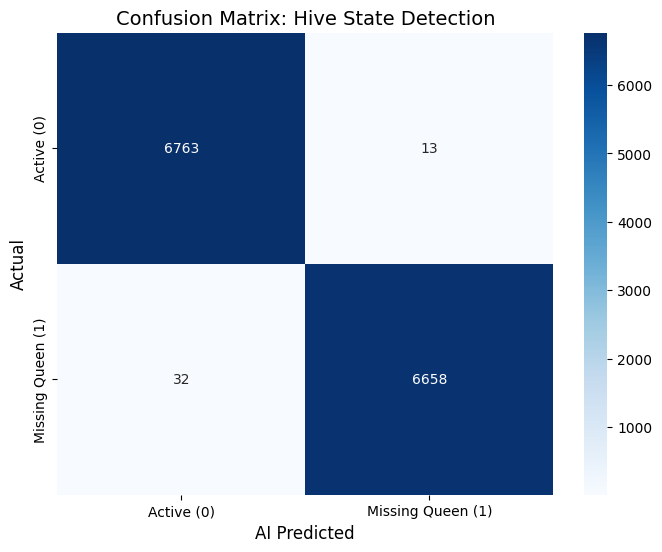

In [ ]:
model = CNN_GRU_HiveModel(num_classes=2).to(DEVICE)
weight_file = 'TrainModel/CNN-GRU-Acc-99.6733.pth'
model.load_state_dict(torch.load(weight_file))
model.eval()

output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

all_preds = []
all_labels = []

print("Last Evaluate")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

target_names = ['Active (0)', 'Missing Queen (1)']
print("\n Classification Report:")
print(classification_report(all_labels, all_preds, target_names=target_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: Hive State Detection', fontsize=14)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('AI Predicted', fontsize=12)

base_filename = os.path.basename(file_path).replace('.wav', '.png')
save_path = os.path.join(output_dir, f"{base_filename}")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

## Grad-CAM (XAI)

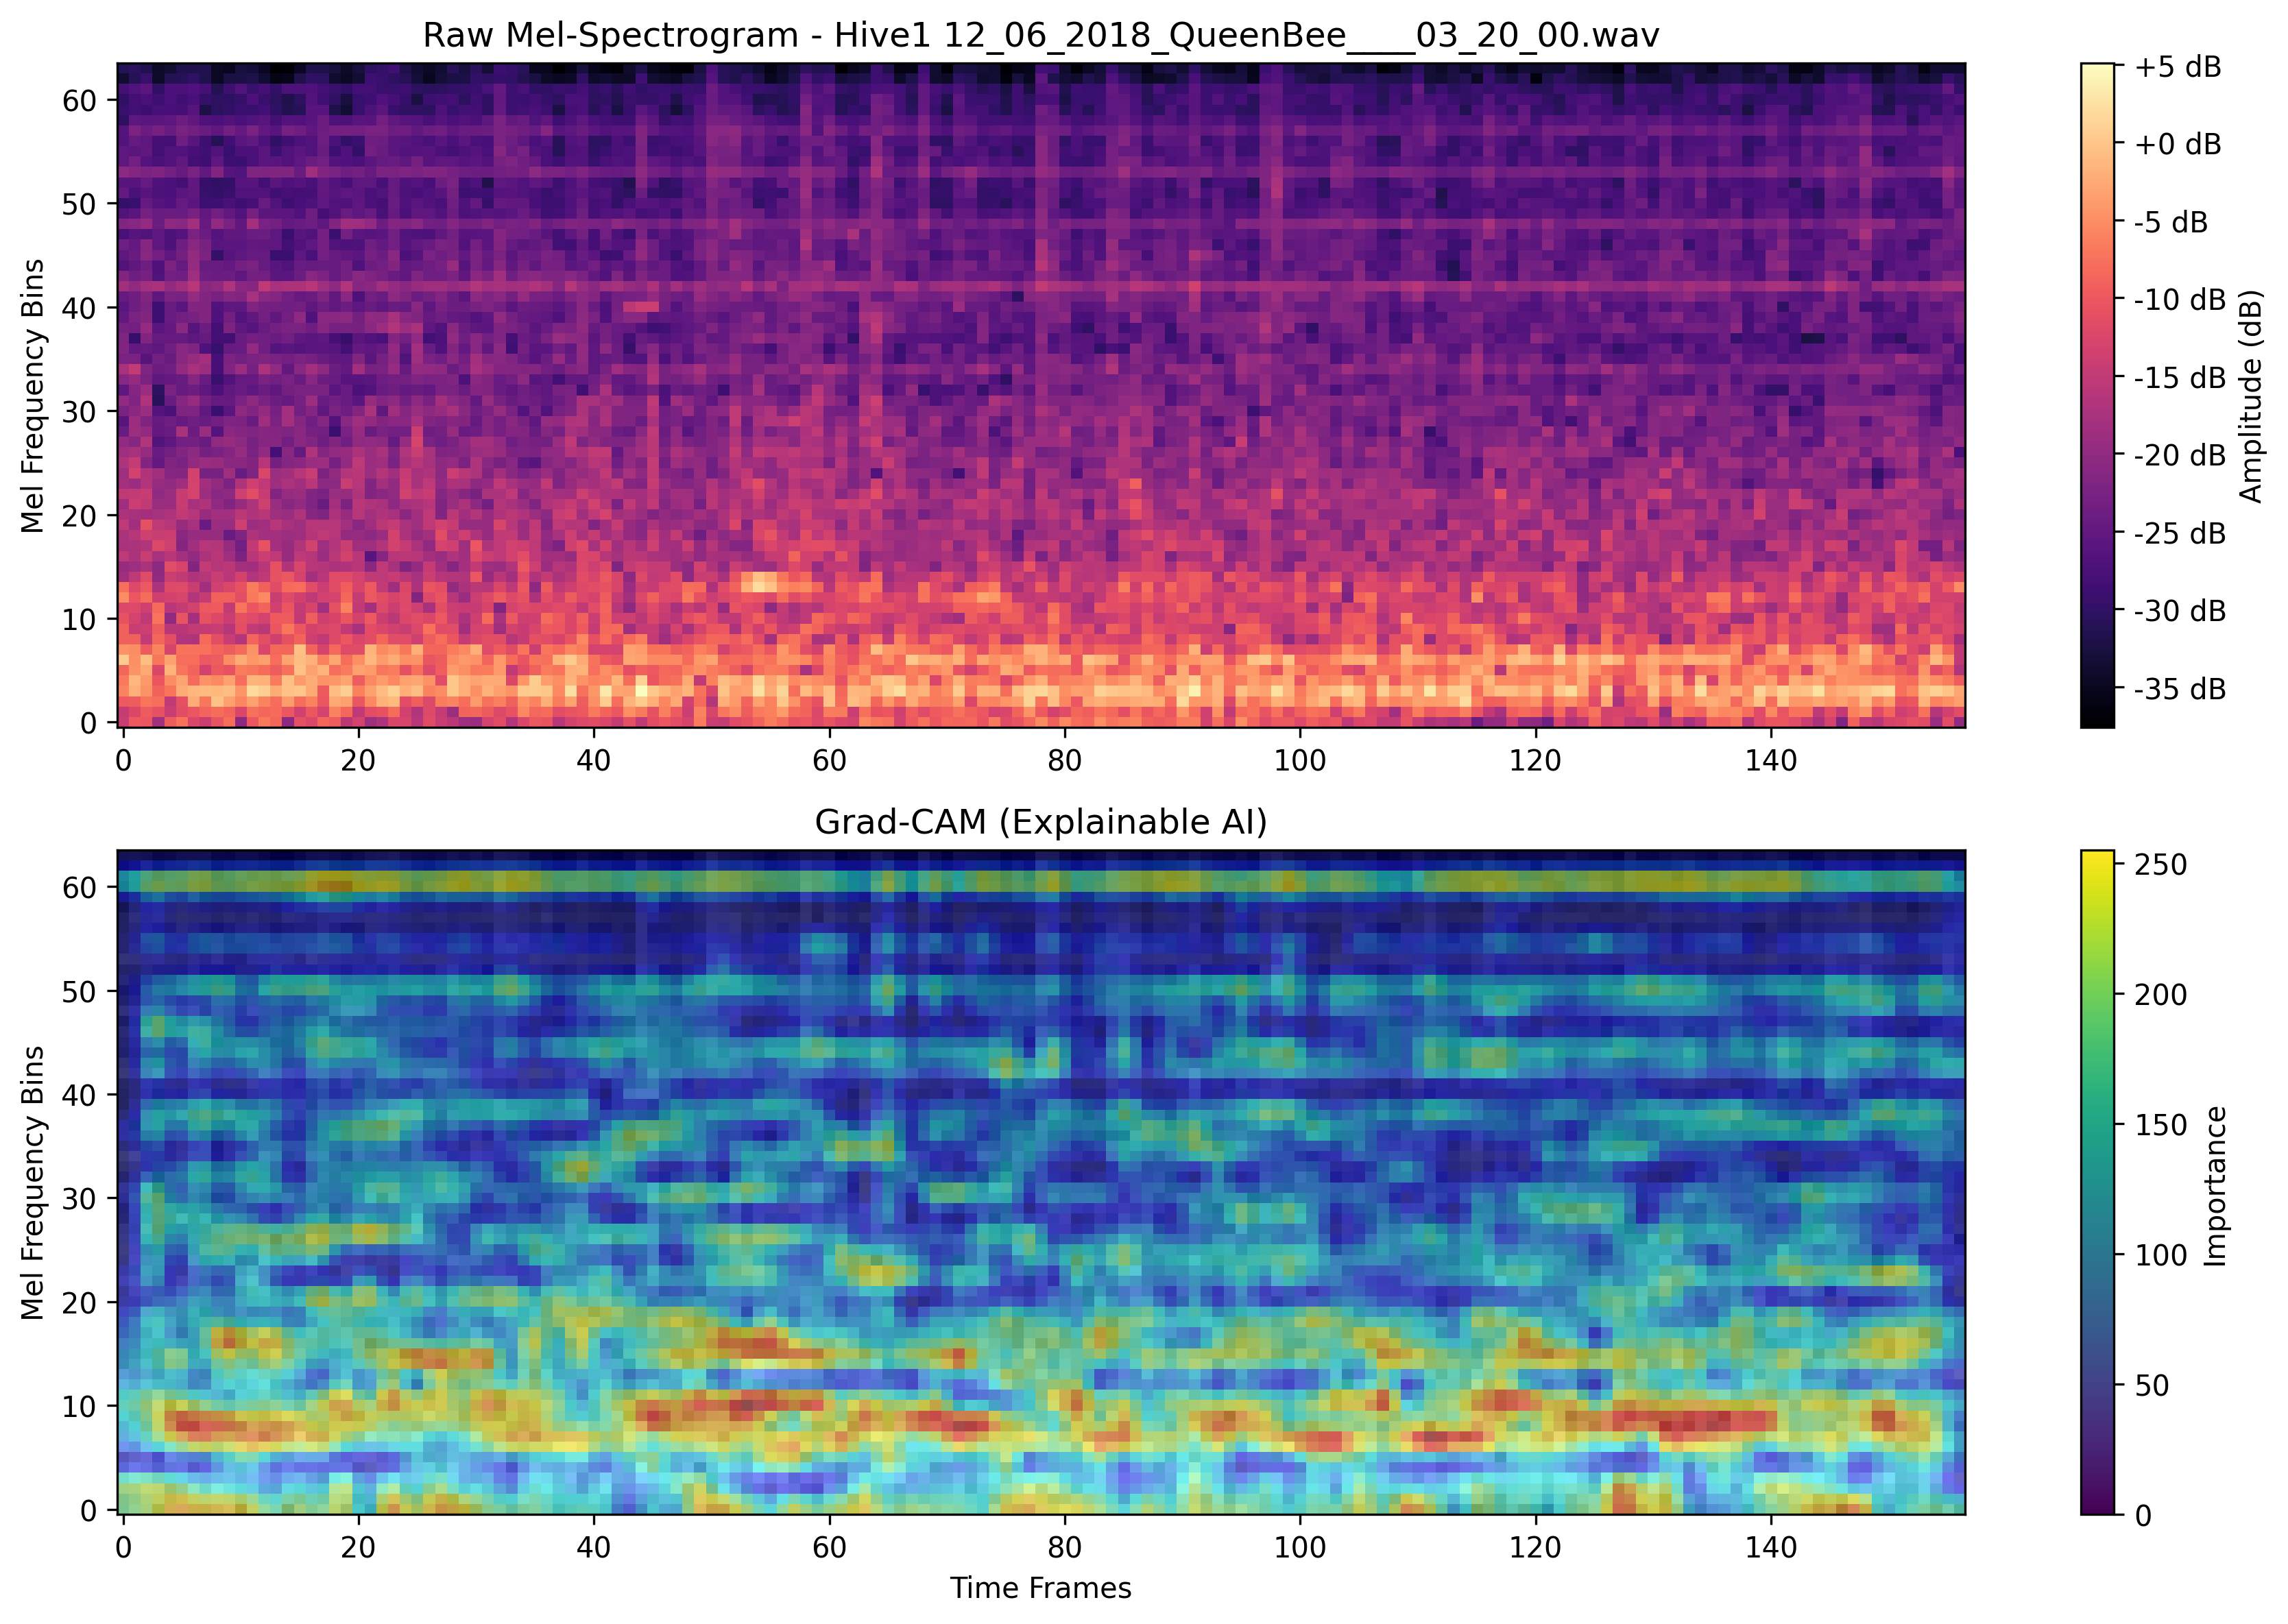

In [ ]:
def analyze_and_plot_audio(file_path, model, device=DEVICE):
    model.eval()
    TARGET_SR = 16000
    output_dir = "output"
    os.makedirs(output_dir, exist_ok=True)
    waveform, sr = torchaudio.load(file_path)
    if sr != TARGET_SR:
        waveform = torchaudio.transforms.Resample(sr, TARGET_SR)(waveform)
    if waveform.shape[0] > 1:
        waveform = torch.mean(waveform, dim=0, keepdim=True)
        
    max_frames = TARGET_SR * 5
    waveform = waveform[:, :max_frames] if waveform.shape[1] > max_frames else F.pad(waveform, (0, max_frames - waveform.shape[1]))
    
    mel_transform = torchaudio.transforms.MelSpectrogram(sample_rate=TARGET_SR, n_mels=64, n_fft=1024, hop_length=512)
    mel_spec_db = torchaudio.transforms.AmplitudeToDB()(mel_transform(waveform))
    input_tensor = mel_spec_db.unsqueeze(0).to(device) # Shape [1, 1, 64, 157]
    
    target_layers = [model.cnn[4]] 
    cam = GradCAM(model=model, target_layers=target_layers)
    
    with torch.backends.cudnn.flags(enabled=False):
        grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0, :]
    
    img = mel_spec_db.squeeze().cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min()) 
    img_rgb = cv2.cvtColor(np.float32(img), cv2.COLOR_GRAY2RGB)
    cam_image = show_cam_on_image(img_rgb, grayscale_cam, use_rgb=True)


    fig, axes = plt.subplots(2, 1, figsize=(12, 8), dpi=300)
    
    # Raw Mel-Spectrogram
    im1 = axes[0].imshow(mel_spec_db[0].numpy(), aspect='auto', origin='lower', cmap='magma')
    axes[0].set_title(f"Raw Mel-Spectrogram - {os.path.basename(file_path)}")
    axes[0].set_ylabel("Mel Frequency Bins")
    fig.colorbar(im1, ax=axes[0], format="%+2.0f dB", label='Amplitude (dB)')
    
    # Grad-CAM
    im2 = axes[1].imshow(cam_image, aspect='auto', origin='lower')
    axes[1].set_title(f"Grad-CAM (Explainable AI)")
    axes[1].set_ylabel("Mel Frequency Bins")
    axes[1].set_xlabel("Time Frames")
    fig.colorbar(im2, ax=axes[1], label='Importance')
    
    plt.tight_layout()
    base_filename = os.path.basename(file_path).replace('.wav', '.png')
    save_path = os.path.join(output_dir, f"AudioAnalysis_{base_filename}")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


analyze_and_plot_audio(r"dataset\Hive1_12_06_2018\Hive1 12_06_2018_QueenBee____03_20_00.wav", model)

In [ ]:
def benchmark_model_speed(model, device=DEVICE, runs=100):
    model.eval()
    dummy_input = torch.randn(1, 1, 64, 157).to(device)
    print("Convolution Neural Network - Gated Recurrent Unit Model")
    print("Warming up GPU...")
    with torch.no_grad():
        with torch.autocast(device_type='cuda'):
            for _ in range(10):
                _ = model(dummy_input)

    print(f"Benchmarking for {runs} runs...")
    
    starter, ender = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
    timings = np.zeros((runs, 1))

    with torch.no_grad():
        with torch.autocast(device_type='cuda'):
            for i in range(runs):
                starter.record()
                _ = model(dummy_input)
                ender.record()
                
                torch.cuda.synchronize()
                curr_time = starter.elapsed_time(ender)
                timings[i] = curr_time

    mean_time = np.sum(timings) / runs
    std_time = np.std(timings)
    fps = 1000 / mean_time
    
    print("\n" + "="*30)
    print("INFERENCE SPEED RESULTS")
    print("="*30)
    print(f"Average Time : {mean_time:.2f} milliseconds / file")
    print(f"Variance (Std): {std_time:.2f} ms")
    print(f"Throughput   : {fps:.2f} files / second")
    print("="*30)

benchmark_model_speed(model)

Convolution Neural Network - Gated Recurrent Unit Model
Warming up GPU...
Benchmarking for 100 runs...

INFERENCE SPEED RESULTS
Average Time : 4.32 milliseconds / file
Variance (Std): 1.48 ms
Throughput   : 231.30 files / second


In [ ]:
def predict_single_audio_cnn_gru(file_path, model, device=DEVICE):
    model.eval()
    TARGET_SR = 16000
    
    try:
        waveform, sr = torchaudio.load(file_path)
        if sr != TARGET_SR:
            resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=TARGET_SR)
            waveform = resampler(waveform)
            
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)
            
        max_frames = TARGET_SR * 5
        if waveform.shape[1] > max_frames:
            waveform = waveform[:, :max_frames]
        elif waveform.shape[1] < max_frames:
            padding = max_frames - waveform.shape[1]
            waveform = F.pad(waveform, (0, padding))

        mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=TARGET_SR, n_mels=64, n_fft=1024, hop_length=512
        )
        db_transform = torchaudio.transforms.AmplitudeToDB()
        
        mel_spec = mel_transform(waveform)
        mel_spec_db = db_transform(mel_spec)
        
        inputs = mel_spec_db.unsqueeze(0).to(device) 

        with torch.no_grad():
            with autocast('cuda'):
                outputs = model(inputs)
                probabilities = F.softmax(outputs, dim=1)[0] 
                
        conf, pred = torch.max(probabilities, 0)
        
        classes = ['Active', 'Missing Queen']
        print(f"File: {os.path.basename(file_path)}")
        print(f"Prediction: {classes[pred.item()]}")
        print(f"Confidence: {conf.item() * 100:.2f}%")
        
        return classes[pred.item()], conf.item()
        
    except Exception as e:
        print(f"Error processing {file_path}: {e}")

predict_single_audio_cnn_gru(r"dataset\Hive1_12_06_2018\Hive1 12_06_2018_QueenBee____03_20_00.wav", model)

File: Hive1 12_06_2018_QueenBee____03_20_00.wav
Prediction: Missing Queen
Confidence: 86.01%


('Missing Queen', 0.8600755929946899)